### Data Exploration

In [9]:
import pandas as pd
import numpy as np

df=pd.read_csv('./dataset/emoji_uncleaned.csv')
mapping=pd.read_csv('./dataset/mapping.csv')
df.head()

,Tweet,Label
0,A little throwback with my favourite person @ ...,0
1,glam on @user yesterday for #kcon makeup using...,7
2,Democracy Plaza in the wake of a stunning outc...,11
3,Then &amp; Now. VILO @ Walt Disney Magic Kingdom,0
4,Who never... @ A Galaxy Far Far Away,2


In [10]:
mapping

,Label,Emoji,Description
0,0,❤️,Red heart
1,1,😍,Smiling face with hearteyes
2,2,😂,Face with tears of joy
3,3,💕,Two hearts
4,4,🔥,Fire
5,5,😊,Smiling face with smiling eyes
6,6,😎,Smiling face with sunglasses
7,7,✨,Sparkles
8,8,💙,Blue heart
9,9,😘,Face blowing a kiss


In [11]:
df.shape

(50000, 2)

C:\Users\singh\AppData\Local\Temp\ipykernel_21628\2966860933.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Label", data=df, palette="plasma")


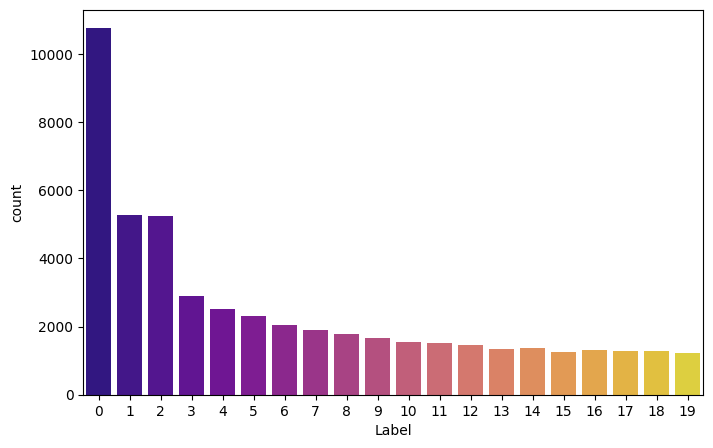

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x="Label", data=df, palette="plasma")
plt.show()

### Data Cleaning

In [13]:
import string
import re

def tweet_clean(tweet):
    tweet = str(tweet).lower()
    rm_mention = re.sub(r'@[A-Za-z0-9]+', '', tweet)                       # remove @mentions
    rm_rt = re.sub(r'RT[/s]+', '', rm_mention)                             # remove RT
    rm_links = re.sub(r'http\S+', '', rm_rt)                               # remove hyperlinks
    rm_links = re.sub(r'https?:\/\/\S+','', rm_links)
    rm_nums = re.sub('[0-9]+', '', rm_links)                               # remove numbers
    rm_punc = [char for char in rm_nums if char not in string.punctuation] # remove punctuations
    rm_punc = ''.join(rm_punc)
    cleaned = rm_punc
    
    return cleaned

df["Tweet"] = df["Tweet"].apply(tweet_clean)
df.head(5)

,Tweet,Label
0,a little throwback with my favourite person w...,0
1,glam on yesterday for kcon makeup using in f...,7
2,democracy plaza in the wake of a stunning outc...,11
3,then amp now vilo walt disney magic kingdom,0
4,who never a galaxy far far away,2


In [14]:
import nltk
import spacy
from nltk.stem import WordNetLemmatizer

nlp = spacy.load("en_core_web_sm")
lemmatizer = WordNetLemmatizer()

def tweet_preprocessing(tweet, nlp=nlp, lemmatizer=lemmatizer):
    
    stop_words = nlp.Defaults.stop_words     
    rm_stop_words_lemma = []
    
    doc = nlp(tweet)
    for token in doc:                                            # tokenization
        if token.text not in stop_words and token.pos_!="PUNCT": 
            lemma_word = lemmatizer.lemmatize(token.text)        # removing stop
            rm_stop_words_lemma.append(lemma_word)               # lemmatizing words 
            
    processed = " ".join(rm_stop_words_lemma)
    return processed

df["Tweet"] = df["Tweet"].apply(tweet_preprocessing)
df.head(5)

,Tweet,Label
0,little throwback favourite person water wall,0
1,glam yesterday kcon makeup featherette,7
2,democracy plaza wake stunning outcome decision...,11
3,amp vilo walt disney magic kingdom,0
4,galaxy far far away,2


In [15]:
df.to_csv('./dataset/emoji_cleaned.csv', index=False)

### Data Preprocessing

In [22]:
import pandas as pd
df=pd.read_csv('./dataset/emoji_cleaned.csv')
df.dropna(inplace=True)
df.head(5)

,Tweet,Label
0,little throwback favourite person water wall,0
1,glam yesterday kcon makeup featherette,7
2,democracy plaza wake stunning outcome decision...,11
3,amp vilo walt disney magic kingdom,0
4,galaxy far far away,2


In [24]:
# Fixing data imbalance
from imblearn.over_sampling import RandomOverSampler

X = df["Tweet"].values
y = df["Label"].values
os = RandomOverSampler()
X = X.reshape(-1,1)
X, y = os.fit_resample(X, y)
X = X.reshape(-1,)
X.shape


(215160,)

In [25]:
import tensorflow as tf
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=80000)
tokenizer.fit_on_texts(X)
X_seqs = tokenizer.texts_to_sequences(X)
X_seqs[:5]


[[27, 303, 1653, 321, 507, 612],
 [2816, 183, 27157, 479, 27158],
 [4270, 495, 852, 999, 5131, 2345, 4271, 1252],
 [6, 43321, 413, 59, 140, 242],
 [2518, 630, 630, 415]]

In [50]:
# save tokenizer
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [30]:
idx2words = tokenizer.index_word
print(idx2words[1])
print(idx2words[2])
print(idx2words[3])

love
new
day


In [31]:
vocab_size = len(tokenizer.index_word)
print("Vocabulary size :",vocab_size)

Vocabulary size : 54782


In [33]:
from keras.preprocessing.sequence import pad_sequences

max_len=40
X_seqs_pd = pad_sequences(X_seqs, truncating="pre", padding="pre", maxlen=max_len)
X_seqs_pd[:1]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,   27,  303, 1653,  321,  507,  612]], dtype=int32)

### Train/Test Split

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test ,y_train, y_test = train_test_split(X_seqs_pd, y, test_size=0.3, random_state=105)
print("Training X Dim ",X_train.shape)
print("Training y Dim ",y_train.shape)

print("Test X Dim ",X_test.shape)
print("Test y Dim ",y_test.shape)

Training X Dim  (150612, 40)
Training y Dim  (150612,)
Test X Dim  (64548, 40)
Test y Dim  (64548,)


### Building Deep Learning Model with LSTM

In [ ]:
from keras.models import Sequential
from keras.layers import Dropout, Dense, LSTM, Bidirectional,Embedding, GlobalMaxPool1D

vocabulary_size = vocab_size
seq_len = 40
embed_len=20

model = Sequential()
model.add(Embedding(vocabulary_size+1, embed_len, input_length=seq_len))
model.add(LSTM(units = 80, return_sequences=True))
model.add(Dropout(0.5))
model.add(LSTM(units = 40))
model.add(Dropout(0.5))
model.add(Dense(units=20, activation='softmax'))

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", mode="min", patience=1,verbose=1)

model.compile(loss = 'categorical_crossentropy',
             optimizer = "adam",
             metrics=["accuracy"])

In [38]:
from keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

### Training the Model

In [39]:
batch_size=128
epochs = 20

model.fit(X_train, y_train_cat, batch_size=batch_size, epochs = epochs, shuffle=True,
          validation_data=(X_test, y_test_cat), callbacks=[early_stop])

Epoch 1/20
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 154s 129ms/step - accuracy: 0.2542 - loss: 2.4426 - val_accuracy: 0.4856 - val_loss: 1.7783
Epoch 2/20
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 75s 64ms/step - accuracy: 0.5932 - loss: 1.4603 - val_accuracy: 0.6816 - val_loss: 1.1632
Epoch 3/20
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 66s 56ms/step - accuracy: 0.7278 - loss: 1.0100 - val_accuracy: 0.7469 - val_loss: 0.9375
Epoch 4/20
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.7862 - loss: 0.7931 - val_accuracy: 0.7768 - val_loss: 0.8325
Epoch 5/20
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.8221 - loss: 0.6604 - val_accuracy: 0.8005 - val_loss: 0.7660
Epoch 6/20
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.8474 - loss: 0.5723 - val_accuracy: 0.8162 - val_loss: 0.7295
Epoch 7/20
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.8639 - loss: 0.5062 - val_accuracy: 0.8290 - val_loss: 0.7042
Epoch 8/20
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.8775

In [40]:
model.save('lstm_model.keras')

### LSTM Bidirectional

In [41]:
from keras.models import Sequential
from keras.layers import Dropout, Dense, LSTM, Bidirectional,Embedding, GlobalMaxPool1D


vocabulary_size = vocab_size
seq_len = 40
embed_len=128

model = Sequential()
model.add(Embedding(vocabulary_size+1, embed_len, input_length=seq_len))
model.add(Bidirectional(LSTM(80,return_sequences=True)))
model.add(Bidirectional(LSTM(80,return_sequences=True)))
model.add(GlobalMaxPool1D())
model.add(Dropout(0.5))
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(20, activation="softmax"))

In [42]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", mode="min", patience=0,verbose=1)

model.compile(loss = 'categorical_crossentropy',
             optimizer = "adam",
             metrics=["accuracy"])

In [43]:
from keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [44]:
batch_size=64
epochs = 15

model.fit(X_train, y_train_cat, batch_size=batch_size, epochs = epochs, 
          shuffle=True,validation_data=(X_test, y_test_cat), callbacks=[early_stop])

Epoch 1/15
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 182s 76ms/step - accuracy: 0.2892 - loss: 2.3245 - val_accuracy: 0.5538 - val_loss: 1.4948
Epoch 2/15
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 161s 68ms/step - accuracy: 0.6647 - loss: 1.1541 - val_accuracy: 0.7307 - val_loss: 0.9227
Epoch 3/15
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 160s 68ms/step - accuracy: 0.7970 - loss: 0.7017 - val_accuracy: 0.8023 - val_loss: 0.6915
Epoch 4/15
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 163s 69ms/step - accuracy: 0.8590 - loss: 0.4960 - val_accuracy: 0.8398 - val_loss: 0.5983
Epoch 5/15
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 162s 69ms/step - accuracy: 0.8966 - loss: 0.3713 - val_accuracy: 0.8609 - val_loss: 0.5629
Epoch 6/15
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 162s 69ms/step - accuracy: 0.9178 - loss: 0.2954 - val_accuracy: 0.8756 - val_loss: 0.5527
Epoch 7/15
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 160s 68ms/step - accuracy: 0.9316 - loss: 0.2438 - val_accuracy: 0.8846 - val_loss: 0.5344
Epoch 8/15
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 159s 67ms/step - accuracy: 

In [49]:
model.save('bi_lstm_model.keras')

In [48]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test)
print(y_test[:1])
print(np.argmax(predictions[:1]))
print(classification_report(y_test, np.argmax(predictions, axis=1)))

2018/2018 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step
[10]
10
              precision    recall  f1-score   support

           0       0.62      0.24      0.35      3270
           1       0.68      0.66      0.67      3214
           2       0.84      0.73      0.78      3247
           3       0.81      0.84      0.83      3225
           4       0.90      0.92      0.91      3251
           5       0.84      0.90      0.87      3250
           6       0.91      0.92      0.92      3251
           7       0.78      0.96      0.86      3154
           8       0.91      0.93      0.92      3198
           9       0.88      0.94      0.91      3153
          10       0.95      0.97      0.96      3145
          11       0.93      0.97      0.95      3216
          12       0.96      0.98      0.97      3288
          13       0.94      0.97      0.96      3205
          14       0.95      0.98      0.96      3278
          15       0.95      0.98      0.97      3204
          16       0.95      

### Testing on custom text

In [52]:
import pickle
import pandas as pd
from keras.models import load_model

max_len=40
mapping=pd.read_csv('./dataset/mapping.csv')

def predict_emoji(text):

    text = tweet_clean(text)
    text = tweet_preprocessing(text)

    with open("tokenizer.pkl", "rb") as f:
        tokenizer = pickle.load(f)

    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, truncating="pre", padding="pre", maxlen=max_len)

    #load model
    model = load_model('bi_lstm_model.keras')

    pred = model.predict(padded)
    pred_class = np.argmax(pred)

    emoji = mapping[mapping["Label"]==pred_class]["Emoji"].values[0]
    
    return emoji

In [65]:
print(predict_emoji("I am excited"))
print(predict_emoji("This is so funny"))
print(predict_emoji("Wow this is amazing !!!!"))
print(predict_emoji("I love food"))
print(predict_emoji("It's so bright and sunny today"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
✨
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
😂
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
😍
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
❤️
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
☀️
